# EDA for ChemXplore ML temporary melting-point dataset

This notebook uses the `SMILES` and `Processed tmp/ºC` columns from `1_ChemXplore_ML_tmp_C.csv`. It reports the melting-point distribution and reproduces the property-distribution EDA for MP, MW, RingCount, TPSA, HBD, and HBA. Train/test splitting and model-related analysis are intentionally excluded.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
import plot_helper_functions as hf

data_path = Path('../0_data/sources/1_ChemXplore_ML_tmp_C.csv')
if not data_path.exists():
    data_path = Path('0_data/sources/1_ChemXplore_ML_tmp_C.csv')

raw = pd.read_csv(data_path, usecols=['SMILES', 'Processed tmp/ºC'])
data = raw.rename(columns={'Processed tmp/ºC': 'MP'}).copy()
data['MP'] = pd.to_numeric(data['MP'], errors='coerce')
data = data.dropna(subset=['SMILES', 'MP']).reset_index(drop=True)

# Requested bins, plus a separate group for values below 0 °C so every valid row is represented.
data['MP_label'] = np.select(
    [data['MP'].between(0, 250, inclusive='both'), data['MP'].gt(250)],
    ['Low MP (0–250 °C)', 'High MP (>250 °C)'],
    default='Below 0 °C'
)
print(f'Dataset: {data_path}')
print(f'Valid rows: {len(data):,}')
print('Minimum MP: {:.1f} °C'.format(data['MP'].min()))
print('Maximum MP: {:.1f} °C'.format(data['MP'].max()))
print('Low MP (0–250 °C): {:,}'.format(data['MP'].between(0, 250, inclusive='both').sum()))
print('High MP (>250 °C): {:,}'.format(data['MP'].gt(250).sum()))
print('Below 0 °C (outside requested bins): {:,}'.format(data['MP'].lt(0).sum()))
display(data.head())

Dataset: ../0_data/1_ChemXplore_ML_tmp_C.csv
Valid rows: 7,646
Minimum MP: -205.1 °C
Maximum MP: 1340.0 °C
Low MP (0–250 °C): 6,031
High MP (>250 °C): 489
Below 0 °C (outside requested bins): 1,126


/opt/anaconda3/envs/Surabie_S_clean_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,SMILES,MP,MP_label
0,COP(=S)(OC)Oc1ccc(Sc2ccc(OP(=S)(OC)OC)cc2)cc1,31.6,Low MP (0–250 °C)
1,CC(C)C1=CC2=CCC3C(C)(C(=O)O)CCCC3(C)C2CC1,173.5,Low MP (0–250 °C)
2,CC(C=CC1(O)C(C)=CC(=O)CC1(C)C)=CC(=O)O,160.0,Low MP (0–250 °C)
3,COc1ccc(-c2cc(=O)c3c(O)cc(O)cc3o2)cc1,263.0,High MP (>250 °C)
4,CCCC(=O)Nc1ccc(OCC(O)CNC(C)C)c(C(C)=O)c1,121.0,Low MP (0–250 °C)


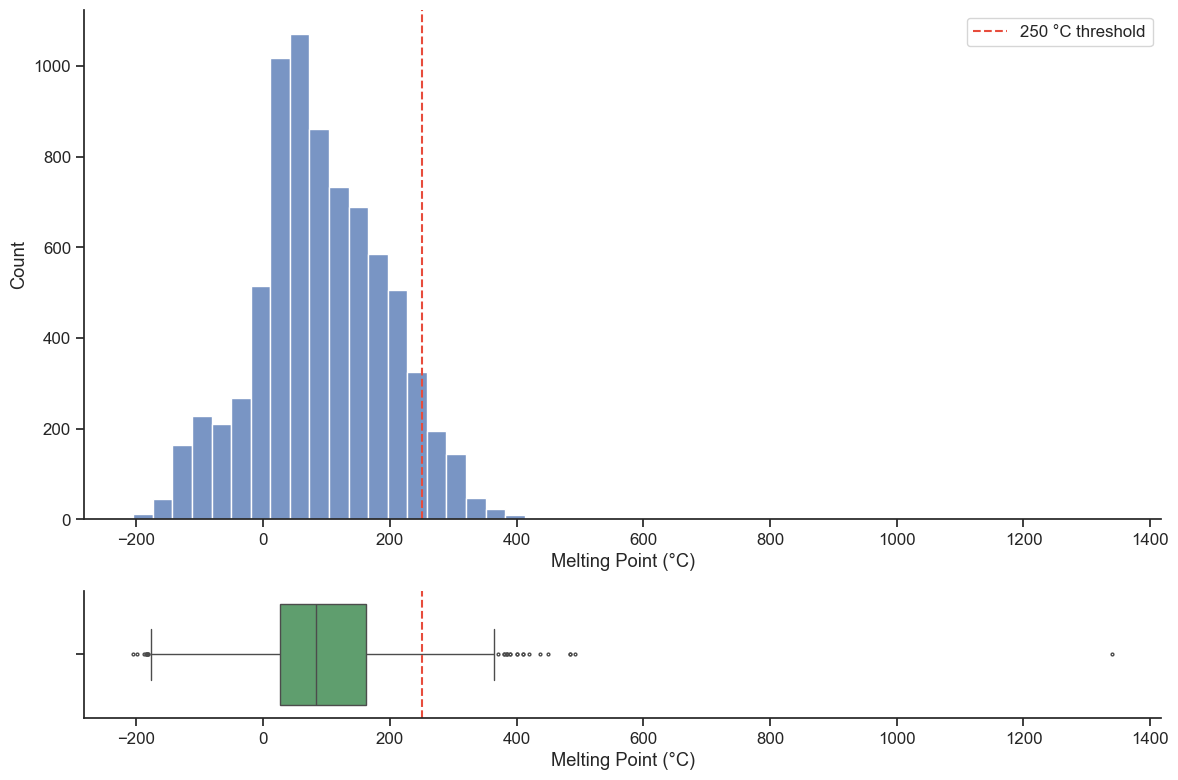

In [2]:
# Melting-point distribution
sns.set_theme(style='ticks', font_scale=1.1)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [4, 1]})
sns.histplot(data=data, x='MP', bins=50, color='#4c72b0', edgecolor='white', ax=axes[0])
axes[0].axvline(250, color='#e74c3c', linestyle='--', linewidth=1.5, label='250 °C threshold')
axes[0].set_xlabel('Melting Point (°C)')
axes[0].set_ylabel('Count')
axes[0].legend()
sns.boxplot(data=data, x='MP', color='#55a868', ax=axes[1], fliersize=2)
axes[1].axvline(250, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Melting Point (°C)')
axes[1].set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

[12:09:47] WARNING: not removing hydrogen atom without neighbors
[12:09:47] WARNING: not removing hydrogen atom without neighbors
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/6_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/6_EDA/plot_helper_functions.py:276: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/6_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

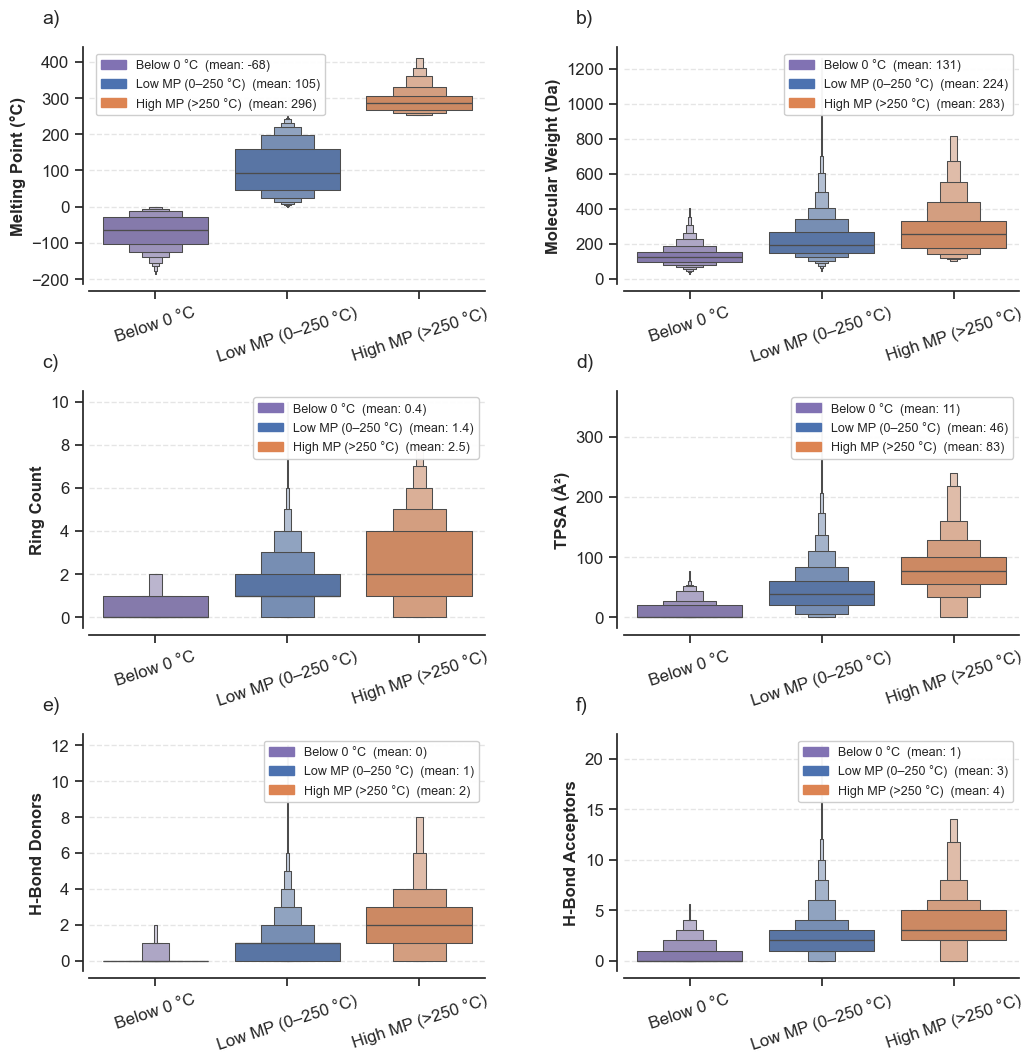

In [3]:
# Reproduce the six-property EDA plot used in EDA.ipynb
properties = [
    ('MP', 'Melting Point (°C)'),
    ('MW', 'Molecular Weight (Da)'),
    ('RingCount', 'Ring Count'),
    ('TPSA', 'TPSA (Å²)'),
    ('HBD', 'H-Bond Donors'),
    ('HBA', 'H-Bond Acceptors'),
]
plot_data = hf._ensure_properties(data, smiles_col='SMILES', props=[p for p, _ in properties])
group_colors = {
    'Below 0 °C': '#8172b3',
    'Low MP (0–250 °C)': '#4c72b0',
    'High MP (>250 °C)': '#dd8452',
}

fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, wspace=0.35, hspace=0.45)
for i, ((row, col), (prop, label)) in enumerate(zip([(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1)], properties)):
    ax = fig.add_subplot(gs[row, col])
    hf.property_plot(plot_data, prop, label, ax=ax, x_col='MP_label',
                     color_scheme=group_colors, smiles_col='SMILES',
                     show_outliers=False, ann=f'{chr(97+i)})', show_legend=True)
    ax.tick_params(axis='x', labelrotation=18)
plt.tight_layout()
plt.show()

# EDA for EGNN Omega melting-point dataset

This section uses the `SMILES` and `Melt_C` columns from `2_EGNN_melt_point.csv`.

In [4]:
egnn_path = Path('../0_data/sources/2_EGNN_melt_point.csv')
if not egnn_path.exists():
    egnn_path = Path('0_data/sources/2_EGNN_melt_point.csv')

egnn_raw = pd.read_csv(egnn_path, usecols=['SMILES', 'Melt_C'])
egnn_data = egnn_raw.rename(columns={'Melt_C': 'MP'}).copy()
egnn_data['MP'] = pd.to_numeric(egnn_data['MP'], errors='coerce')
egnn_data = egnn_data.dropna(subset=['SMILES', 'MP']).reset_index(drop=True)
egnn_data['MP_label'] = np.select(
    [egnn_data['MP'].between(0, 250, inclusive='both'), egnn_data['MP'].gt(250)],
    ['Low MP (0–250 °C)', 'High MP (>250 °C)'],
    default='Below 0 °C'
)
print(f'Dataset: {egnn_path}')
print(f'Valid rows: {len(egnn_data):,}')
print('Minimum MP: {:.1f} °C'.format(egnn_data['MP'].min()))
print('Maximum MP: {:.1f} °C'.format(egnn_data['MP'].max()))
print('Low MP (0–250 °C): {:,}'.format(egnn_data['MP'].between(0, 250, inclusive='both').sum()))
print('High MP (>250 °C): {:,}'.format(egnn_data['MP'].gt(250).sum()))
print('Below 0 °C (outside requested bins): {:,}'.format(egnn_data['MP'].lt(0).sum()))
display(egnn_data.head())

Dataset: ../0_data/2_EGNN_Omega_melt_point.csv
Valid rows: 237,406
Minimum MP: -187.6 °C
Maximum MP: 505.0 °C
Low MP (0–250 °C): 222,191
High MP (>250 °C): 13,307
Below 0 °C (outside requested bins): 1,908


,SMILES,MP,MP_label
0,C(C1=CC=CC=C1)OC2=NC(=C3N=CN(C3=N2)CC4=CC=C(C=...,122.0,Low MP (0–250 °C)
1,CC=1C=CC(=CC1)S(=O)(=O)C2CCCCC2=O,78.0,Low MP (0–250 °C)
2,COC=1C=C(C=CC1)C2=C(N=C(N2)C3=CC=C(C=C3)NC)C(=...,249.5,Low MP (0–250 °C)
3,C(=C(Cl)Cl)(C1=CC=C(C=C1)F)C=2C=CC(=CC2)F,77.0,Low MP (0–250 °C)
4,COC(C(NC(C(NC(=O)OCC1=CC=CC=C1)CC2=CC=CC=C2)=O...,114.5,Low MP (0–250 °C)


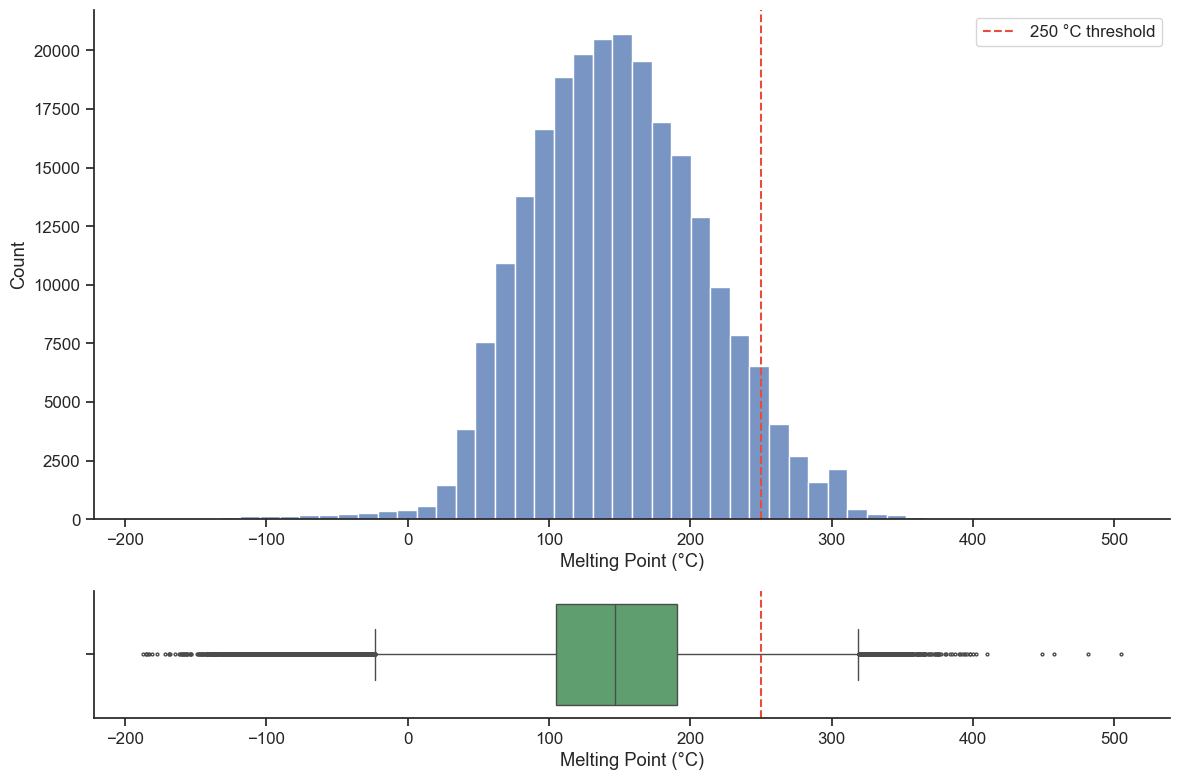

In [5]:
# EGNN Omega melting-point distribution
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [4, 1]})
sns.histplot(data=egnn_data, x='MP', bins=50, color='#4c72b0', edgecolor='white', ax=axes[0])
axes[0].axvline(250, color='#e74c3c', linestyle='--', linewidth=1.5, label='250 °C threshold')
axes[0].set_xlabel('Melting Point (°C)')
axes[0].set_ylabel('Count')
axes[0].legend()
sns.boxplot(data=egnn_data, x='MP', color='#55a868', ax=axes[1], fliersize=2)
axes[1].axvline(250, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Melting Point (°C)')
axes[1].set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

/Users/sdl5_mp/Documents/GitHub/melting_point_2026/6_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/6_EDA/plot_helper_functions.py:276: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([_LABEL_MAP.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
/Users/sdl5_mp/Documents/GitHub/melting_point_2026/6_EDA/plot_helper_functions.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x=x_col, y=prop, order=group_order,
/Users/sdl5_mp/Documents/G

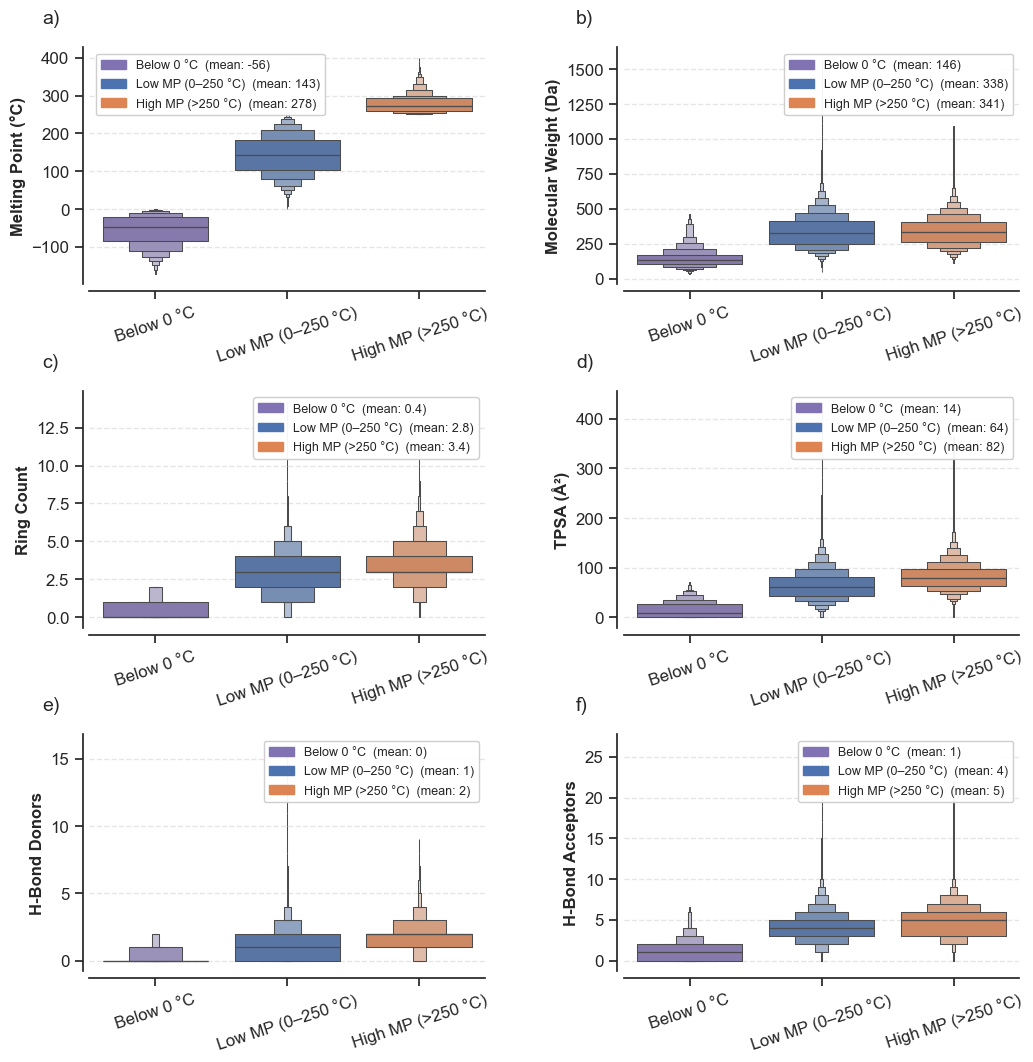

In [6]:
# EGNN Omega six-property EDA plot
egnn_plot_data = hf._ensure_properties(egnn_data, smiles_col='SMILES', props=[p for p, _ in properties])
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(3, 2, figure=fig, wspace=0.35, hspace=0.45)
for i, ((row, col), (prop, label)) in enumerate(zip([(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1)], properties)):
    ax = fig.add_subplot(gs[row, col])
    hf.property_plot(egnn_plot_data, prop, label, ax=ax, x_col='MP_label',
                     color_scheme=group_colors, smiles_col='SMILES',
                     show_outliers=False, ann=f'{chr(97+i)})', show_legend=True)
    ax.tick_params(axis='x', labelrotation=18)
plt.tight_layout()
plt.show()